# Anomaly Detection in Manufacturing — 3 Model Comparison
**SimpleAutoencoder | Attention UNet | Convolutional VAE**

All-in-one notebook: Training, Evaluation, and Comparative Analysis on MVTec AD

In [ ]:
# === IMPORTS & CONFIG ===
import os, random, numpy as np, cv2, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, f1_score
from glob import glob
from tqdm.auto import tqdm
import torchvision.models as models
import torchvision.transforms.functional as TF
from itertools import combinations
import pandas as pd

class Config:
    data_root = r"D:\Project_CV\data"
    category = "metal_nut"
    image_size = 256
    batch_size = 8
    epochs = 50
    lr = 1e-4
    val_ratio = 0.1
    w_mse, w_ssim, w_edge = 0.6, 0.3, 0.1
    canny_low, canny_high = 50, 150
    seed = 42
    patience, min_delta, grad_clip = 10, 1e-5, 0.5
    heatmap_vmax = 0.3
    unet_epochs, unet_patience = 25, 7
    simple_epochs, vae_epochs, vae_beta = 50, 50, 1.0

cfg = Config()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device} | CUDA: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
random.seed(cfg.seed); np.random.seed(cfg.seed); torch.manual_seed(cfg.seed)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(cfg.seed)

Device: cuda | CUDA: NVIDIA GeForce RTX 3050 Laptop GPU


## Preprocessing

In [ ]:
# === PREPROCESSING ===
def load_gray(path, size=256):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None: img = np.array(Image.open(path).convert('L'))
    return cv2.resize(img, (size, size)).astype(np.float32) / 255.0

def compute_edges(gray, low=50, high=150):
    return cv2.Canny((gray * 255).astype(np.uint8), low, high).astype(np.float32) / 255.0

def compute_contours(edges):
    contours, _ = cv2.findContours((edges * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contour_map = np.zeros_like(edges)
    if contours: cv2.drawContours(contour_map, contours, -1, 1.0, 1)
    return contour_map

def preprocess(path, cfg):
    gray = load_gray(path, cfg.image_size)
    edges = compute_edges(gray, cfg.canny_low, cfg.canny_high)
    fused = np.stack([gray, edges, compute_contours(edges)], axis=0)
    return torch.tensor(fused, dtype=torch.float32), torch.tensor(gray[None], dtype=torch.float32)

## Loss Functions, Scoring & Scheduler

In [ ]:
# === LOSS FUNCTIONS, SCORING & SCHEDULER ===

class SSIMLoss(nn.Module):
    def __init__(self, win=11):
        super().__init__()
        self.win, self.C1, self.C2 = win, 0.01**2, 0.03**2
        g = torch.exp(-(torch.arange(win, dtype=torch.float32) - win // 2) ** 2 / (2 * 1.5 ** 2))
        g = g / g.sum()
        self.register_buffer('window', g.outer(g).view(1, 1, win, win))
    def forward(self, pred, target):
        w, p = self.window.to(pred.device).type_as(pred), self.win // 2
        mu1, mu2 = F.conv2d(pred, w, padding=p), F.conv2d(target, w, padding=p)
        s1 = F.conv2d(pred ** 2, w, padding=p) - mu1 ** 2
        s2 = F.conv2d(target ** 2, w, padding=p) - mu2 ** 2
        s12 = F.conv2d(pred * target, w, padding=p) - mu1 * mu2
        ssim = ((2*mu1*mu2 + self.C1) * (2*s12 + self.C2)) / ((mu1**2 + mu2**2 + self.C1) * (s1.clamp(1e-8) + s2.clamp(1e-8) + self.C2))
        return (1 - ssim.clamp(-1, 1)).mean()

class EdgeLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer('sx', torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32).view(1,1,3,3))
        self.register_buffer('sy', torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32).view(1,1,3,3))
    def forward(self, pred, target):
        def edges(x):
            gx = F.conv2d(x, self.sx.to(x.device).type_as(x), padding=1)
            gy = F.conv2d(x, self.sy.to(x.device).type_as(x), padding=1)
            return torch.sqrt(gx ** 2 + gy ** 2 + 1e-8)
        return F.mse_loss(edges(pred), edges(target))

class VGGPerceptualLoss(nn.Module):
    def __init__(self, device='cuda'):
        super().__init__()
        self.vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features[:16].to(device).eval()
        for p in self.vgg.parameters(): p.requires_grad = False
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
        self.std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)
    def forward(self, x, y):
        if x.shape[1] == 1: x, y = x.repeat(1, 3, 1, 1), y.repeat(1, 3, 1, 1)
        return F.mse_loss(self.vgg((x - self.mean) / self.std), self.vgg((y - self.mean) / self.std))

class ImprovedTotalLoss(nn.Module):
    def __init__(self, device='cuda', mse_w=0.4, ssim_w=0.2, edge_w=0.1, perc_w=0.3):
        super().__init__()
        self.fns = [nn.MSELoss(), SSIMLoss(), EdgeLoss(), VGGPerceptualLoss(device)]
        self.w = (mse_w, ssim_w, edge_w, perc_w)
    def forward(self, pred, target):
        vals = [fn(pred, target) for fn in self.fns]
        total = sum(w * v for w, v in zip(self.w, vals))
        return total, {n: v.item() for n, v in zip(['mse', 'ssim', 'edge', 'perc'], vals)}

class VAELoss(nn.Module):
    def __init__(self, device='cuda', beta=0.5, mse_w=0.4, ssim_w=0.3, edge_w=0.1, perc_w=0.2):
        super().__init__()
        self.beta = beta
        self.fns = [nn.MSELoss(), SSIMLoss(), EdgeLoss(), VGGPerceptualLoss(device)]
        self.w = (mse_w, ssim_w, edge_w, perc_w)
    def forward(self, pred, target, mu, logvar):
        vals = [fn(pred, target) for fn in self.fns]
        recon = sum(w * v for w, v in zip(self.w, vals))
        kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        comps = {n: v.item() for n, v in zip(['mse', 'ssim', 'edge', 'perc'], vals)}
        comps.update({'kl': kl.item(), 'recon': recon.item()})
        return recon + self.beta * kl, comps

def compute_anomaly_score(y, recon, ssim_loss_fn=None):
    mse = ((y - recon) ** 2).view(y.size(0), -1).mean(dim=1)
    if ssim_loss_fn is not None:
        ssim_score = torch.stack([ssim_loss_fn(recon[i:i+1], y[i:i+1]) for i in range(y.size(0))]).squeeze()
        if ssim_score.dim() == 0: ssim_score = ssim_score.unsqueeze(0)
    else:
        ssim_score = torch.zeros(y.size(0), device=y.device)
    diff_smooth = F.avg_pool2d((y - recon) ** 2, kernel_size=5, stride=1, padding=2)
    return mse + 0.3 * ssim_score, diff_smooth

class WarmupCosineScheduler:
    def __init__(self, optimizer, warmup_epochs, total_epochs, min_lr=1e-6):
        self.optimizer, self.warmup, self.total = optimizer, warmup_epochs, total_epochs
        self.base_lr, self.min_lr = optimizer.param_groups[0]['lr'], min_lr
    def step(self, epoch):
        if epoch < self.warmup:
            lr = self.base_lr * (epoch + 1) / self.warmup
        else:
            progress = (epoch - self.warmup) / max(self.total - self.warmup, 1)
            lr = self.min_lr + 0.5 * (self.base_lr - self.min_lr) * (1 + np.cos(np.pi * progress))
        for pg in self.optimizer.param_groups: pg['lr'] = lr
        return lr

print("✅ Loss functions, scoring & scheduler ready")

✅ All loss functions defined:
   SSIMLoss, EdgeLoss, TotalLoss, VGGPerceptualLoss, ImprovedTotalLoss, VAELoss
✅ Improved anomaly scoring (per-image SSIM)
✅ WarmupCosineScheduler


## Model 1: Attention U-Net Autoencoder

In [ ]:
# === ATTENTION UNET MODEL ===

class ChannelAttention(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        mid = max(ch // r, 1)
        self.fc = nn.Sequential(nn.Conv2d(ch, mid, 1, bias=False), nn.ReLU(True), nn.Conv2d(mid, ch, 1, bias=False))
        self.sig = nn.Sigmoid()
    def forward(self, x):
        return x * self.sig(self.fc(F.adaptive_avg_pool2d(x, 1)) + self.fc(F.adaptive_max_pool2d(x, 1)))

class SpatialAttention(nn.Module):
    def __init__(self, ks=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, ks, padding=ks // 2, bias=False)
    def forward(self, x):
        return x * torch.sigmoid(self.conv(torch.cat([x.mean(1, keepdim=True), x.amax(1, keepdim=True)], 1)))

class CBAM(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.ca, self.sa = ChannelAttention(ch, r), SpatialAttention()
    def forward(self, x): return self.sa(self.ca(x))

class AttentionGate(nn.Module):
    def __init__(self, gate_c, skip_c):
        super().__init__()
        inter = max(skip_c // 2, 1)
        self.W_gate = nn.Sequential(nn.Conv2d(gate_c, inter, 1, bias=False), nn.BatchNorm2d(inter))
        self.W_skip = nn.Sequential(nn.Conv2d(skip_c, inter, 1, bias=False), nn.BatchNorm2d(inter))
        self.psi = nn.Sequential(nn.Conv2d(inter, 1, 1, bias=False), nn.BatchNorm2d(1), nn.Sigmoid())
    def forward(self, gate, skip):
        g, s = self.W_gate(gate), self.W_skip(skip)
        if g.shape[2:] != s.shape[2:]: g = F.interpolate(g, size=s.shape[2:], mode='bilinear', align_corners=True)
        return skip * self.psi(F.relu(g + s, inplace=True))

class DoubleConvAttn(nn.Module):
    def __init__(self, ic, oc, attn=True):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(ic, oc, 3, padding=1, bias=False), nn.BatchNorm2d(oc), nn.ReLU(True),
            nn.Conv2d(oc, oc, 3, padding=1, bias=False), nn.BatchNorm2d(oc), nn.ReLU(True))
        self.attn = CBAM(oc) if attn else nn.Identity()
    def forward(self, x): return self.attn(self.conv(x))

class DownAttn(nn.Module):
    def __init__(self, ic, oc, attn=True):
        super().__init__()
        self.pool, self.conv = nn.MaxPool2d(2), DoubleConvAttn(ic, oc, attn)
    def forward(self, x): return self.conv(self.pool(x))

class UpAttn(nn.Module):
    def __init__(self, ic, sc, oc, attn=True):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.attn_gate = AttentionGate(ic, sc) if attn else None
        self.conv = DoubleConvAttn(ic + sc, oc, attn=False)
    def forward(self, x, skip):
        x = self.up(x)
        dh, dw = skip.size(2) - x.size(2), skip.size(3) - x.size(3)
        if dh or dw: x = F.pad(x, [dw // 2, dw - dw // 2, dh // 2, dh - dh // 2])
        if self.attn_gate: skip = self.attn_gate(gate=x, skip=skip)
        return self.conv(torch.cat([skip, x], dim=1))

class AttentionUNet(nn.Module):
    def __init__(self, in_c=3, out_c=1, base=32):
        super().__init__()
        self.enc1 = DoubleConvAttn(in_c, base)
        self.enc2, self.enc3, self.enc4 = DownAttn(base, base*2), DownAttn(base*2, base*4), DownAttn(base*4, base*8)
        self.bottleneck = DownAttn(base*8, base*16)
        self.dec4 = UpAttn(base*16, base*8, base*8)
        self.dec3 = UpAttn(base*8, base*4, base*4)
        self.dec2 = UpAttn(base*4, base*2, base*2)
        self.dec1 = UpAttn(base*2, base, base)
        self.out = nn.Sequential(nn.Conv2d(base, out_c, 1), nn.Sigmoid())
        self._init_weights()
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(e1); e3 = self.enc3(e2); e4 = self.enc4(e3)
        b = self.bottleneck(e4)
        return self.out(self.dec1(self.dec2(self.dec3(self.dec4(b, e4), e3), e2), e1))

model = AttentionUNet().to(device)
print(f"Attention UNet params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
with torch.no_grad():
    dummy = torch.randn(1, 3, 256, 256).to(device)
    out = model(dummy)
    print(f"Input: {dummy.shape} → Output: {out.shape}")
    assert out.shape == (1, 1, 256, 256)
print("✅ Attention UNet ready")

Attention UNet params: 8,025,507
Input:  torch.Size([1, 3, 256, 256])
Output: torch.Size([1, 1, 256, 256])
✅ Attention UNet ready


## Model 2: Simple Convolutional Autoencoder
A plain encoder-decoder **without skip connections** — forces the bottleneck to learn a compressed representation. Anomalies should be harder to reconstruct since the model only learns normal patterns.

In [ ]:
# === SIMPLE CONVOLUTIONAL AUTOENCODER ===

class SimpleAutoencoder(nn.Module):
    def __init__(self, in_c=3, out_c=1, base=32):
        super().__init__()
        def cbr2(ic, oc): return nn.Sequential(
            nn.Conv2d(ic, oc, 3, padding=1, bias=False), nn.BatchNorm2d(oc), nn.ReLU(True),
            nn.Conv2d(oc, oc, 3, padding=1, bias=False), nn.BatchNorm2d(oc), nn.ReLU(True))
        def up_cbr2(ic, oc): return nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(ic, oc, 3, padding=1, bias=False), nn.BatchNorm2d(oc), nn.ReLU(True),
            nn.Conv2d(oc, oc, 3, padding=1, bias=False), nn.BatchNorm2d(oc), nn.ReLU(True))
        self.enc1, self.pool1 = cbr2(in_c, base), nn.MaxPool2d(2)
        self.enc2, self.pool2 = cbr2(base, base*2), nn.MaxPool2d(2)
        self.enc3, self.pool3 = cbr2(base*2, base*4), nn.MaxPool2d(2)
        self.enc4, self.pool4 = cbr2(base*4, base*8), nn.MaxPool2d(2)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(base*8, base*16, 3, padding=1, bias=False), nn.BatchNorm2d(base*16), nn.ReLU(True),
            nn.Conv2d(base*16, base*8, 3, padding=1, bias=False), nn.BatchNorm2d(base*8), nn.ReLU(True))
        self.dec4, self.dec3, self.dec2 = up_cbr2(base*8, base*4), up_cbr2(base*4, base*2), up_cbr2(base*2, base)
        self.dec1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(base, base, 3, padding=1, bias=False), nn.BatchNorm2d(base), nn.ReLU(True),
            nn.Conv2d(base, out_c, 1), nn.Sigmoid())
        self._init_weights()
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
    def encoder(self, x):
        e1 = self.pool1(self.enc1(x)); e2 = self.pool2(self.enc2(e1))
        e3 = self.pool3(self.enc3(e2))
        return self.bottleneck(self.pool4(self.enc4(e3)))
    def decoder(self, z): return self.dec1(self.dec2(self.dec3(self.dec4(z))))
    def forward(self, x): return self.decoder(self.encoder(x))

model_simple_test = SimpleAutoencoder().to(device)
print(f"Simple Autoencoder params: {sum(p.numel() for p in model_simple_test.parameters() if p.requires_grad):,}")
with torch.no_grad():
    dummy = torch.randn(1, 3, 256, 256).to(device)
    out = model_simple_test(dummy)
    print(f"Input: {dummy.shape} → Output: {out.shape}")
    assert out.shape == (1, 1, 256, 256)
print("✅ Simple Autoencoder ready")
del model_simple_test
if torch.cuda.is_available(): torch.cuda.empty_cache()

Simple Autoencoder params: 4,124,865
Input:  torch.Size([1, 3, 256, 256])
Output: torch.Size([1, 1, 256, 256])
✅ Simple Autoencoder ready


## Model 3: Convolutional Variational Autoencoder (VAE)
Adds a **latent vector** with mean (μ) and variance (σ²), regularized by KL divergence to enforce a smooth latent space. Anomalies map to low-probability regions → high reconstruction error + high KL.

The reparameterization trick enables backpropagation: z = μ + σ · ε, where ε ~ N(0, I)

In [ ]:
# === CONVOLUTIONAL VAE ===

class ConvVAE(nn.Module):
    def __init__(self, in_c=3, out_c=1, base=32, latent_dim=256):
        super().__init__()
        self.latent_dim, self.base = latent_dim, base
        def enc_layer(ic, oc): return nn.Sequential(
            nn.Conv2d(ic, oc, 4, stride=2, padding=1, bias=False), nn.BatchNorm2d(oc), nn.ReLU(True))
        def dec_layer(ic, oc): return nn.Sequential(
            nn.ConvTranspose2d(ic, oc, 4, stride=2, padding=1, bias=False), nn.BatchNorm2d(oc), nn.ReLU(True))
        self.enc = nn.Sequential(enc_layer(in_c, base), enc_layer(base, base*2), enc_layer(base*2, base*4),
                                 enc_layer(base*4, base*8), enc_layer(base*8, base*16))
        self.flatten_size = base * 16 * 8 * 8
        self.fc_mu = nn.Linear(self.flatten_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_size, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, self.flatten_size)
        self.dec = nn.Sequential(dec_layer(base*16, base*8), dec_layer(base*8, base*4), dec_layer(base*4, base*2),
                                 dec_layer(base*2, base), dec_layer(base, base),
                                 nn.Conv2d(base, out_c, 3, padding=1), nn.Sigmoid())
        self._init_weights()
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)
    def encode(self, x):
        h = self.enc(x).view(x.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)
    def reparameterize(self, mu, logvar):
        if self.training: return mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        return mu
    def decode(self, z):
        return self.dec(self.fc_decode(z).view(-1, self.base * 16, 8, 8))
    def forward(self, x):
        mu, logvar = self.encode(x)
        return self.decode(self.reparameterize(mu, logvar)), mu, logvar

model_vae_test = ConvVAE(latent_dim=256).to(device)
print(f"ConvVAE params: {sum(p.numel() for p in model_vae_test.parameters() if p.requires_grad):,}")
with torch.no_grad():
    dummy = torch.randn(1, 3, 256, 256).to(device)
    recon, mu, logvar = model_vae_test(dummy)
    print(f"Input: {dummy.shape} → Output: {recon.shape}, mu={mu.shape}")
    assert recon.shape == (1, 1, 256, 256)
print("✅ ConvVAE ready")
del model_vae_test
if torch.cuda.is_available(): torch.cuda.empty_cache()

ConvVAE params: 30,790,881
Input:   torch.Size([1, 3, 256, 256])
Output:  torch.Size([1, 1, 256, 256])
Latent:  mu=torch.Size([1, 256]), logvar=torch.Size([1, 256])
✅ ConvVAE ready


---
## Data Loading & Augmented Dataset
Uses the augmented dataset with random flips and rotations. Edges and contours are **recomputed after augmentation** to ensure consistency.

Loaded 220 train samples (augment=False)


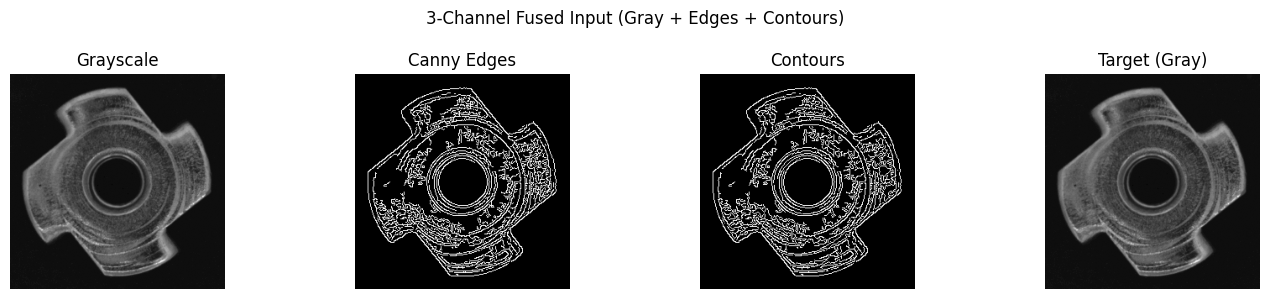

In [ ]:
# === AUGMENTED DATASET ===

class MVTecDatasetAug(Dataset):
    def __init__(self, cfg, split='train', augment=True):
        self.cfg, self.split, self.augment = cfg, split, augment and (split == 'train')
        self.samples = []
        split_dir = os.path.join(cfg.data_root, cfg.category, split)
        gt_dir = os.path.join(cfg.data_root, cfg.category, 'ground_truth')
        
        for defect in sorted(os.listdir(split_dir)):
            defect_path = os.path.join(split_dir, defect)
            if not os.path.isdir(defect_path): continue
            is_good = defect.lower() == 'good'
            
            for f in glob(os.path.join(defect_path, '*.*')):
                if not f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')): continue
                mask_path = None
                if not is_good:
                    name = os.path.splitext(os.path.basename(f))[0]
                    
                    for ext in ['.png', '_mask.png']:
                        mp = os.path.join(gt_dir, defect, name + ext)
                        if os.path.exists(mp): mask_path = mp; break
                        
                self.samples.append({'path': f, 'label': 0 if is_good else 1, 'mask': mask_path, 'defect': defect})
                
        if split == 'train': random.shuffle(self.samples)
        print(f"Loaded {len(self.samples)} {split} samples (augment={self.augment})")
        
    def __len__(self): return len(self.samples)
    
    def _apply_augment(self, gray, mask):
        gray_pil = Image.fromarray((gray * 255).astype(np.uint8))
        mask_pil = Image.fromarray((mask * 255).astype(np.uint8))
        if random.random() > 0.5: gray_pil, mask_pil = TF.hflip(gray_pil), TF.hflip(mask_pil)
        if random.random() > 0.5: gray_pil, mask_pil = TF.vflip(gray_pil), TF.vflip(mask_pil)
        angle = random.choice([0, 90, 180, 270])
        if angle: gray_pil, mask_pil = TF.rotate(gray_pil, angle), TF.rotate(mask_pil, angle)
        return np.array(gray_pil).astype(np.float32) / 255.0, np.array(mask_pil).astype(np.float32) / 255.0
    
    def __getitem__(self, idx):
        s = self.samples[idx]
        gray = load_gray(s['path'], self.cfg.image_size)
        if s['mask']:
            mask = cv2.resize(cv2.imread(s['mask'], cv2.IMREAD_GRAYSCALE),
                              (self.cfg.image_size, self.cfg.image_size))
            mask = (mask > 127).astype(np.float32)
        else:
            mask = np.zeros((self.cfg.image_size, self.cfg.image_size), dtype=np.float32)
        if self.augment: gray, mask = self._apply_augment(gray, mask)
        edges = compute_edges(gray, self.cfg.canny_low, self.cfg.canny_high)
        fused = np.stack([gray, edges, compute_contours(edges)], axis=0)
        return {'fused': torch.tensor(fused, dtype=torch.float32),
                'gray': torch.tensor(gray[None], dtype=torch.float32),
                'mask': torch.tensor(mask[None], dtype=torch.float32),
                'label': s['label'], 'defect': s['defect']}

# Visualize
train_ds_viz = MVTecDatasetAug(cfg, 'train', augment=False)
sample = train_ds_viz[0]
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (img, t) in zip(axes, [(sample['fused'][0], 'Grayscale'), (sample['fused'][1], 'Canny Edges'),
                                (sample['fused'][2], 'Contours'), (sample['gray'][0], 'Target')]):
    ax.imshow(img, cmap='gray'); ax.set_title(t); ax.axis('off')
plt.suptitle('3-Channel Fused Input (Gray + Edges + Contours)'); plt.tight_layout(); plt.show()
del train_ds_viz

---
## Unified Training & Evaluation
One training function that handles all 3 models (SimpleAE, AttentionUNet, ConvVAE) with:
- **Improved loss** (MSE + SSIM + Edge + VGG Perceptual)
- **Warmup + Cosine LR scheduling**
- **Validation-based early stopping**
- **Gradient clipping** for stability

In [ ]:
# === UNIFIED TRAINING FUNCTION ===

def train_model(model, model_name, cfg, epochs=50, patience=10, is_vae=False):
    train_ds = MVTecDatasetAug(cfg, 'train', augment=True)
    test_ds = MVTecDatasetAug(cfg, 'test', augment=False)
    
    n_val = max(1, int(len(train_ds) * cfg.val_ratio))
    train_sub, val_sub = torch.utils.data.random_split(
        train_ds, [len(train_ds) - n_val, n_val], generator=torch.Generator().manual_seed(cfg.seed))
    
    train_loader = DataLoader(train_sub, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_sub, batch_size=cfg.batch_size, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)
    train_loader_eval = DataLoader(MVTecDatasetAug(cfg, 'train', augment=False),
                                   batch_size=cfg.batch_size, shuffle=False, num_workers=0)
    
    if is_vae: criterion = VAELoss(device=str(device), beta=cfg.vae_beta)
    elif model_name == "AttentionUNet": criterion = ImprovedTotalLoss(device=str(device), mse_w=0.6, ssim_w=0.1, edge_w=0.1, perc_w=0.2)
    else: criterion = ImprovedTotalLoss(device=str(device))
    
    optimizer = AdamW(model.parameters(), lr=cfg.lr, weight_decay=1e-4)
    scheduler = WarmupCosineScheduler(optimizer, warmup_epochs=5, total_epochs=epochs)
    train_losses, val_losses, best_val, pat_cnt = [], [], float('inf'), 0
    save_path = f'best_{model_name}_{cfg.category}.pth'
    
    print(f"\n{'='*55}\n  Training {model_name} | Train:{len(train_sub)} Val:{n_val} Test:{len(test_ds)} Ep:{epochs}\n{'='*55}")

    for epoch in range(1, epochs + 1):
        lr = scheduler.step(epoch - 1)
        model.train(); epoch_loss = 0; comps = {}
        pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False)
        
        for batch in pbar:
            x, y = batch['fused'].to(device), batch['gray'].to(device)
            optimizer.zero_grad()
            if is_vae:
                recon, mu, logvar = model(x); loss, comps = criterion(recon, y, mu, logvar)
            else:
                loss, comps = criterion(model(x), y)
            if torch.isnan(loss) or torch.isinf(loss): continue
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step(); epoch_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.5f}'})
        train_losses.append(epoch_loss / max(len(train_loader), 1))

        model.eval(); vl = 0
        with torch.no_grad():
            for batch in val_loader:
                x, y = batch['fused'].to(device), batch['gray'].to(device)
                if is_vae:
                    recon, mu, logvar = model(x); loss, _ = criterion(recon, y, mu, logvar)
                else:
                    loss, _ = criterion(model(x), y)
                vl += loss.item()
        vl /= max(len(val_loader), 1); val_losses.append(vl)

        if vl < best_val - cfg.min_delta:
            best_val, pat_cnt = vl, 0
            torch.save({'model': model.state_dict(), 'epoch': epoch, 'loss': best_val}, save_path)
        else: pat_cnt += 1
        if epoch % 5 == 0 or epoch == 1:
            kl_str = f" | KL:{comps.get('kl', 0):.5f}" if is_vae else ""
            print(f"  Ep {epoch:3d} | T:{train_losses[-1]:.5f} V:{vl:.5f} LR:{lr:.1e} P:{pat_cnt}/{patience}{kl_str}")
        if pat_cnt >= patience: print(f"\n  Early stopping at epoch {epoch}"); break

    ckpt = torch.load(save_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model'])
    print(f"  ✅ {model_name} done! Best val: {best_val:.5f} (epoch {ckpt['epoch']})")
    return model, train_losses, val_losses, test_loader, train_loader_eval

print("✅ Training function ready")

✅ Unified training function ready (handles SimpleAE, AttentionUNet, ConvVAE)
   AttentionUNet: weaker perceptual loss (0.2) to prevent overfitting
   ConvVAE: β=1.0 for stronger KL signal


In [ ]:
# === EVALUATION FUNCTION ===

def evaluate_model(model, model_name, cfg, test_loader, train_loader=None, is_vae=False):
    model.eval()
    ssim_scorer = SSIMLoss().to(device)
    all_labels, scores = [], {'MSE': [], 'MSE+SSIM': [], 'Top-2%': []}
    if is_vae: scores['Recon+KL'] = []
    pixel_scores, pixel_labels = [], []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Scoring {model_name}", leave=False):
            x, y, masks, labels = batch['fused'].to(device), batch['gray'].to(device), batch['mask'], batch['label']
            if is_vae:
                recon, mu, logvar = model(x)
                kl_per = -0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1)
            else:
                recon = model(x)
            mse_map = (y - recon) ** 2
            mse_score = mse_map.view(mse_map.size(0), -1).mean(dim=1)
            scores['MSE'].extend(mse_score.cpu().numpy())
            img_sc, diff_sm = compute_anomaly_score(y, recon, ssim_loss_fn=ssim_scorer)
            scores['MSE+SSIM'].extend(img_sc.cpu().numpy())
            mse_flat = mse_map.view(mse_map.size(0), -1)
            k = max(1, int(mse_flat.size(1) * 0.02))
            scores['Top-2%'].extend(mse_flat.topk(k, dim=1)[0].mean(dim=1).cpu().numpy())
            if is_vae: scores['Recon+KL'].extend((mse_score + 0.1 * kl_per).cpu().numpy())
            all_labels.extend(labels.numpy())
            diff_maps = diff_sm.cpu()
            for i in range(len(labels)):
                if labels[i] == 1:
                    pixel_scores.extend(diff_maps[i].flatten().numpy())
                    pixel_labels.extend(masks[i].flatten().numpy())

    all_labels = np.array(all_labels)
    scoring_methods = {k: np.array(v) for k, v in scores.items()}
    method_names = list(scoring_methods.keys())
    best_auroc, best_method, best_scores = 0, '', None

    for name, sc in scoring_methods.items():
        sc_eval = sc.copy()
        if all_labels.sum() > 0 and (all_labels == 0).sum() > 0:
            if sc_eval[all_labels == 0].mean() > sc_eval[all_labels == 1].mean(): sc_eval = -sc_eval
        try: auroc = roc_auc_score(all_labels, sc_eval)
        except: auroc = 0.5
        if auroc > best_auroc: best_auroc, best_method, best_scores = auroc, name, sc_eval

    # Normalize & combine
    normalized = []
    for name in method_names:
        s = scoring_methods[name].copy()
        if all_labels.sum() > 0 and (all_labels == 0).sum() > 0:
            if s[all_labels == 0].mean() > s[all_labels == 1].mean(): s = -s
        s = (s - s.min()) / (s.max() - s.min() + 1e-8)
        normalized.append(s)
    best_combo = best_auroc
    for i in range(len(normalized)):
        for j in range(i + 1, len(normalized)):
            for w in np.arange(0, 1.05, 0.1):
                try:
                    auroc = roc_auc_score(all_labels, w * normalized[i] + (1 - w) * normalized[j])
                    if auroc > best_combo:
                        best_combo, best_scores, best_method = auroc, w * normalized[i] + (1 - w) * normalized[j], "Combined"
                except: pass
    if len(normalized) >= 3:
        for idx_t in combinations(range(len(normalized)), 3):
            i, j, k = idx_t
            for w1 in np.arange(0, 1.05, 0.2):
                for w2 in np.arange(0, 1.05 - w1, 0.2):
                    w3 = round(1.0 - w1 - w2, 1)
                    if w3 < -0.01: continue
                    try:
                        c = w1 * normalized[i] + w2 * normalized[j] + w3 * normalized[k]
                        auroc = roc_auc_score(all_labels, c)
                        if auroc > best_combo:
                            best_combo, best_scores, best_method = auroc, c, "Combined"
                    except: pass
    best_auroc = best_combo

    fpr, tpr, thresholds = roc_curve(all_labels, best_scores)
    j_idx = np.argmax(tpr - fpr)
    preds = (best_scores >= thresholds[j_idx]).astype(int)
    cm = confusion_matrix(all_labels, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    pixel_auroc = 0.0
    pa, pl = np.array(pixel_scores), np.array(pixel_labels)
    if len(pl) > 0 and len(np.unique(pl)) > 1:
        pixel_auroc = roc_auc_score(pl, pa)
        if pixel_auroc < 0.5: pixel_auroc = 1 - pixel_auroc

    results = {'model': model_name, 'best_method': best_method, 'image_auroc': best_auroc,
               'pixel_auroc': pixel_auroc, 'accuracy': (preds == all_labels).mean(),
               'balanced_accuracy': (sens + spec) / 2, 'f1_score': f1_score(all_labels, preds, zero_division=0),
               'sensitivity': sens, 'specificity': spec, 'precision': tp / (tp + fp) if (tp + fp) > 0 else 0.0,
               'threshold': thresholds[j_idx], 'confusion_matrix': cm,
               'fpr': fpr, 'tpr': tpr, 'scores': best_scores, 'labels': all_labels}

    print(f"\n{'='*55}\n  {model_name} — {cfg.category}")
    print(f"  AUROC: {best_auroc:.4f} (img) / {pixel_auroc:.4f} (px) | Method: {best_method}")
    print(f"  BalAcc: {(sens+spec)/2:.4f} | F1: {results['f1_score']:.4f} | Sens: {sens:.4f} | Spec: {spec:.4f}")
    print(f"  CM: TN={tn} FP={fp} FN={fn} TP={tp}\n{'='*55}")
    return results

print("✅ Evaluation function ready")

✅ Improved evaluation function ready (multi-strategy + full combination + balanced metrics)


---
## Train & Evaluate All 3 Models
Runs each model sequentially on the chosen **manufacturing category** and collects results for comparison.

In [ ]:
# === TRAIN & EVALUATE ALL 3 MODELS ===
cfg.category = "metal_nut"
all_results, all_train_losses, all_val_losses, all_models = {}, {}, {}, {}

model_configs = [
    ("SimpleAE", SimpleAutoencoder(), cfg.simple_epochs, cfg.patience, False),
    ("AttentionUNet", AttentionUNet(), cfg.unet_epochs, cfg.unet_patience, False),
    ("ConvVAE", ConvVAE(latent_dim=256), cfg.vae_epochs, cfg.patience, True),
]
for i, (name, mdl, ep, pat, vae) in enumerate(model_configs, 1):
    print(f"\n{'█'*55}\n  MODEL {i}/3: {name.upper()}\n{'█'*55}")
    mdl = mdl.to(device)
    print(f"  Parameters: {sum(p.numel() for p in mdl.parameters() if p.requires_grad):,}")
    mdl, tl, vl, test_ld, train_ld_eval = train_model(mdl, name, cfg, epochs=ep, patience=pat, is_vae=vae)
    all_results[name] = evaluate_model(mdl, name, cfg, test_ld, train_ld_eval, is_vae=vae)
    all_train_losses[name], all_val_losses[name], all_models[name] = tl, vl, mdl
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print(f"\n{'█'*55}\n  ALL 3 MODELS TRAINED & EVALUATED!\n{'█'*55}")


███████████████████████████████████████████████████████
  MODEL 1/3: SIMPLE AUTOENCODER
███████████████████████████████████████████████████████
  Parameters: 4,124,865
Loaded 220 train samples (augment=True)
Loaded 116 test samples (augment=False)
Loaded 220 train samples (augment=False)

  Training SimpleAE on 'metal_nut'
  Train: 198 | Val: 22 | Test: 116
  Epochs: 50 | Patience: 10
  Loss: ImprovedTotalLoss (MSE=0.4, SSIM=0.2, Edge=0.1, Perc=0.3)


  Epoch   1 | Train: 3.03406 | Val: 2.24256 | LR: 2.0e-05 | Pat: 0/10


  Epoch   5 | Train: 1.40782 | Val: 1.50279 | LR: 1.0e-04 | Pat: 0/10


  Epoch  10 | Train: 1.13258 | Val: 1.16402 | LR: 9.8e-05 | Pat: 0/10


  Epoch  15 | Train: 1.04415 | Val: 1.08201 | LR: 9.1e-05 | Pat: 0/10


...

  Epoch  35 | Train: 0.99360 | Val: 1.00045 | LR: 2.9e-05 | Pat: 0/10 | KL: 0.05015


  Epoch  40 | Train: 0.97470 | Val: 0.99154 | LR: 1.5e-05 | Pat: 1/10 | KL: 0.03478


  Epoch  45 | Train: 0.96473 | Val: 0.97239 | LR: 5.3e-06 | Pat: 2/10 | KL: 0.03516


  Epoch  50 | Train: 0.95490 | Val: 0.96962 | LR: 1.1e-06 | Pat: 1/10 | KL: 0.03075

  ✅ ConvVAE training complete! Best val loss: 0.96822 (epoch 49)

  Evaluating ConvVAE...



  Method             AUROC   Direction
  -----------------------------------
  MSE               0.7103    INVERTED
  MSE+SSIM          0.7645    INVERTED
  Top-2%            0.7544    INVERTED
  Recon+KL          0.3917          OK
  Combined          0.7761  (MSE+SSIM=0.7, Top-2%=0.3)

  ConvVAE RESULTS — metal_nut
  Best scoring:      Combined
  Image AUROC:       0.7761
  Pixel AUROC:       0.7956
  Accuracy:          0.7845
  Balanced Accuracy: 0.7626
  Sensitivity (TPR): 0.7979  (anomaly detection rate)
  Specificity (TNR): 0.7273  (normal recognition rate)
  Precision:         0.9259
  F1 Score:          0.8571
  Threshold:         0.863326
  Test set:          22 normal / 94 anomaly
  Confusion Matrix:
    TN=  16  FP=   6
    FN=  19  TP=  75


███████████████████████████████████████████████████████
  ALL 3 MODELS TRAINED & EVALUATED!
███████████████████████████████████████████████████████


---
## Comparative Analysis
Side-by-side comparison of all 3 models: loss curves, ROC curves, score distributions, reconstruction quality, and anomaly heatmaps.

In [ ]:
# === SUMMARY TABLE ===
summary_data = [{
    'Model': n, 'Params': f"{sum(p.numel() for p in all_models[n].parameters() if p.requires_grad):,}",
    'Img AUROC': f"{r['image_auroc']:.4f}", 'Pix AUROC': f"{r['pixel_auroc']:.4f}",
    'Bal. Acc': f"{r['balanced_accuracy']:.4f}", 'F1': f"{r['f1_score']:.4f}",
    'Sens.': f"{r['sensitivity']:.4f}", 'Spec.': f"{r['specificity']:.4f}", 'Method': r['best_method'],
} for n, r in all_results.items()]

df_summary = pd.DataFrame(summary_data)
print(f"\n{'='*100}\n  MODEL COMPARISON — {cfg.category.upper()}\n{'='*100}")
print(df_summary.to_string(index=False))
test_labels = list(all_results.values())[0]['labels']
n_n, n_a = int((test_labels == 0).sum()), int((test_labels == 1).sum())
print(f"\n  Test set: {n_n} normal / {n_a} anomaly (ratio {max(n_n, n_a) / max(min(n_n, n_a), 1):.1f}:1)")
for metric, key in [('Image AUROC', 'image_auroc'), ('Pixel AUROC', 'pixel_auroc'),
                     ('Balanced Acc', 'balanced_accuracy'), ('F1 Score', 'f1_score')]:
    best = max(all_results, key=lambda k: all_results[k][key])
    print(f"  🏆 Best ({metric}): {best} — {all_results[best][key]:.4f}")


  MODEL COMPARISON — METAL_NUT
        Model     Params Img AUROC Pix AUROC Bal. Acc     F1  Sens.  Spec.  Prec.   Method
     SimpleAE  4,124,865    0.6591    0.7598   0.6862 0.8770 0.8723 0.5000 0.8817 Combined
AttentionUNet  8,025,507    0.8245    0.7748   0.7935 0.8242 0.7234 0.8636 0.9577 Combined
      ConvVAE 30,790,881    0.7761    0.7956   0.7626 0.8571 0.7979 0.7273 0.9259 Combined

  ⚠️  Test set: 22 normal / 94 anomaly (ratio 4.3:1)
  ⚠️  Class imbalance detected — use Balanced Acc & AUROC, not raw Accuracy

  🏆 Best (Image AUROC):   AttentionUNet — 0.8245
  🏆 Best (Pixel AUROC):   ConvVAE — 0.7956
  🏆 Best (Balanced Acc):  AttentionUNet — 0.7935
  🏆 Best (F1 Score):      SimpleAE — 0.8770


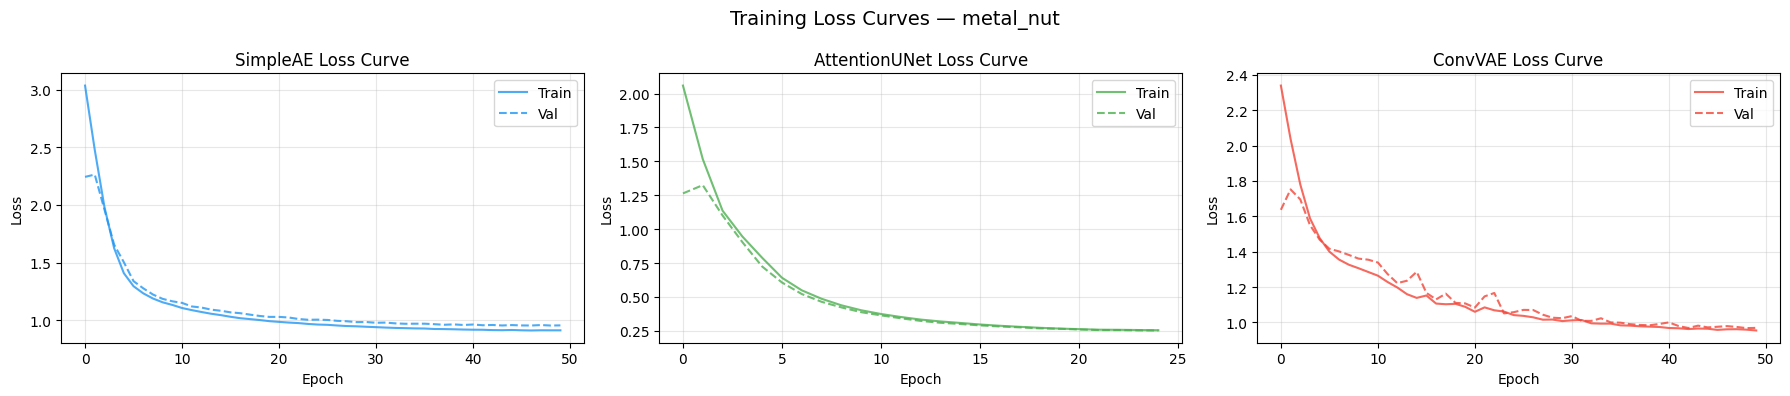

In [ ]:
# === LOSS CURVES ===
colors = {'SimpleAE': '#2196F3', 'AttentionUNet': '#4CAF50', 'ConvVAE': '#F44336'}
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (n, tl) in zip(axes, all_train_losses.items()):
    ax.plot(tl, label='Train', color=colors[n], alpha=0.8)
    ax.plot(all_val_losses[n], label='Val', color=colors[n], ls='--', alpha=0.8)
    ax.set_title(f'{n} Loss'); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle(f'Training Loss — {cfg.category}', fontsize=14); plt.tight_layout()
plt.savefig(f'loss_curves_{cfg.category}.png', dpi=150, bbox_inches='tight'); plt.show()

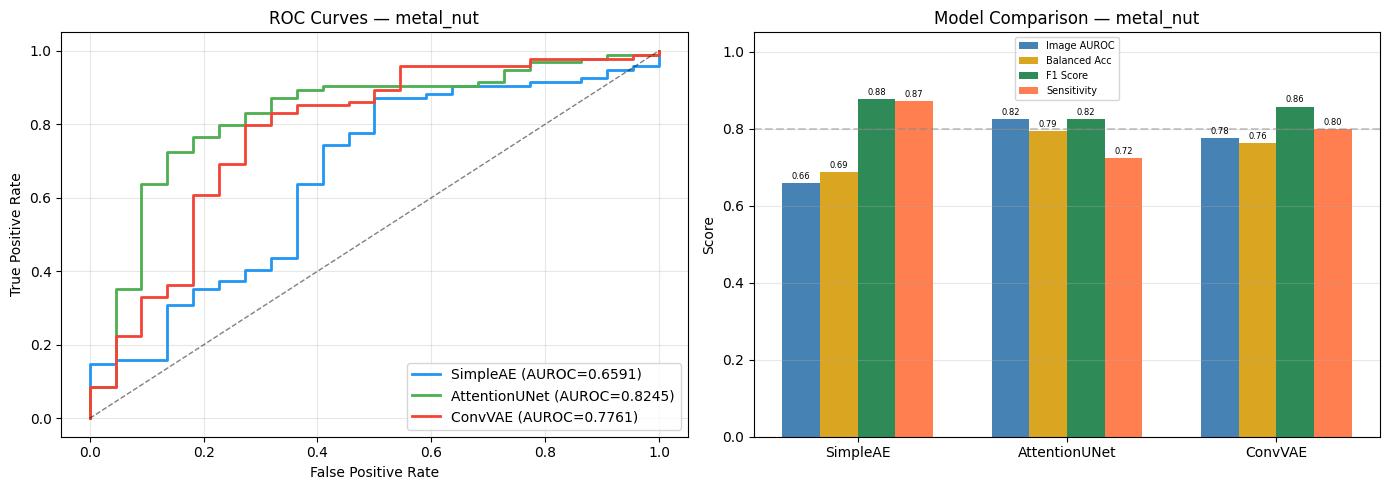

In [ ]:
# === ROC CURVES & BAR CHART ===
colors = {'SimpleAE': '#2196F3', 'AttentionUNet': '#4CAF50', 'ConvVAE': '#F44336'}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for n, r in all_results.items():
    ax1.plot(r['fpr'], r['tpr'], color=colors[n], lw=2, label=f"{n} ({r['image_auroc']:.4f})")
ax1.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5); ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title(f'ROC — {cfg.category}'); ax1.legend(loc='lower right'); ax1.grid(True, alpha=0.3)

ml = list(all_results.keys()); x = np.arange(len(ml)); w = 0.18
metrics = [('Image AUROC', 'image_auroc', 'steelblue'), ('Balanced Acc', 'balanced_accuracy', 'goldenrod'),
           ('F1', 'f1_score', 'seagreen'), ('Sensitivity', 'sensitivity', 'coral')]
for i, (label, key, color) in enumerate(metrics):
    vals = [all_results[m][key] for m in ml]
    bars = ax2.bar(x + (i - 1.5) * w, vals, w, label=label, color=color)
    for b in bars:
        ax2.annotate(f'{b.get_height():.2f}', xy=(b.get_x() + b.get_width() / 2, b.get_height()),
                     xytext=(0, 3), textcoords="offset points", ha='center', fontsize=6)
ax2.set_xticks(x); ax2.set_xticklabels(ml); ax2.set_ylim(0, 1.05); ax2.legend(fontsize=7)
ax2.set_title(f'Comparison — {cfg.category}'); ax2.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(f'roc_comparison_{cfg.category}.png', dpi=150, bbox_inches='tight'); plt.show()

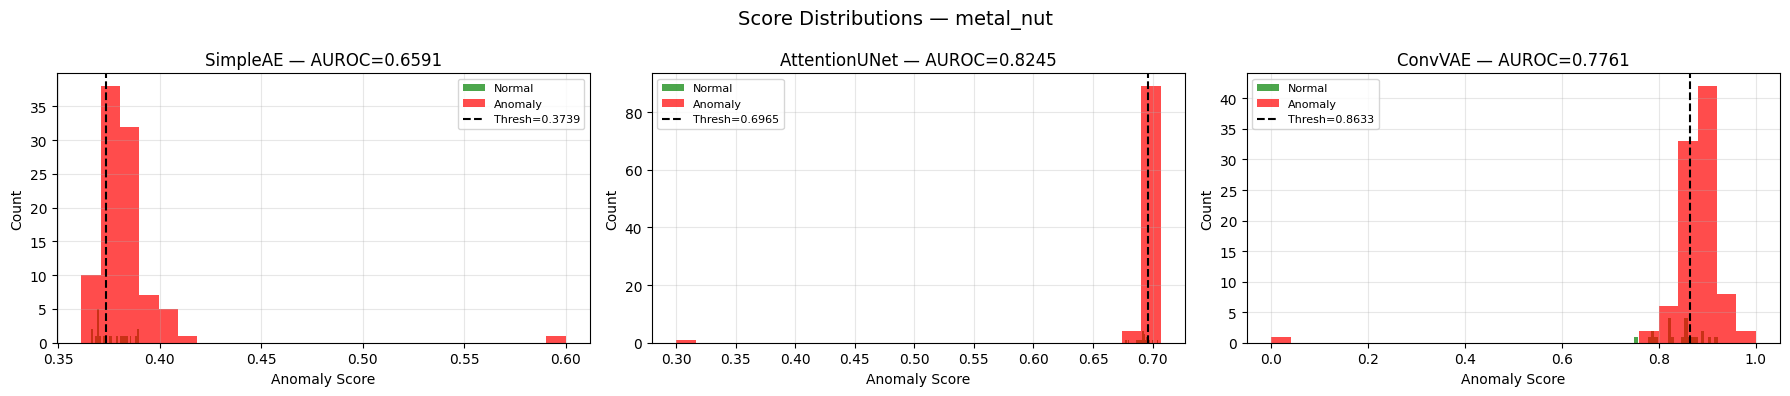

In [ ]:
# === SCORE DISTRIBUTIONS ===
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (n, r) in zip(axes, all_results.items()):
    ax.hist(r['scores'][r['labels'] == 0], bins=25, alpha=0.7, label='Normal', color='green')
    ax.hist(r['scores'][r['labels'] == 1], bins=25, alpha=0.7, label='Anomaly', color='red')
    ax.axvline(r['threshold'], color='k', ls='--', lw=1.5, label=f"Thresh={r['threshold']:.4f}")
    ax.set_title(f"{n} — AUROC={r['image_auroc']:.4f}"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle(f'Score Distributions — {cfg.category}', fontsize=14); plt.tight_layout()
plt.savefig(f'score_distributions_{cfg.category}.png', dpi=150, bbox_inches='tight'); plt.show()

Loaded 116 test samples (augment=False)


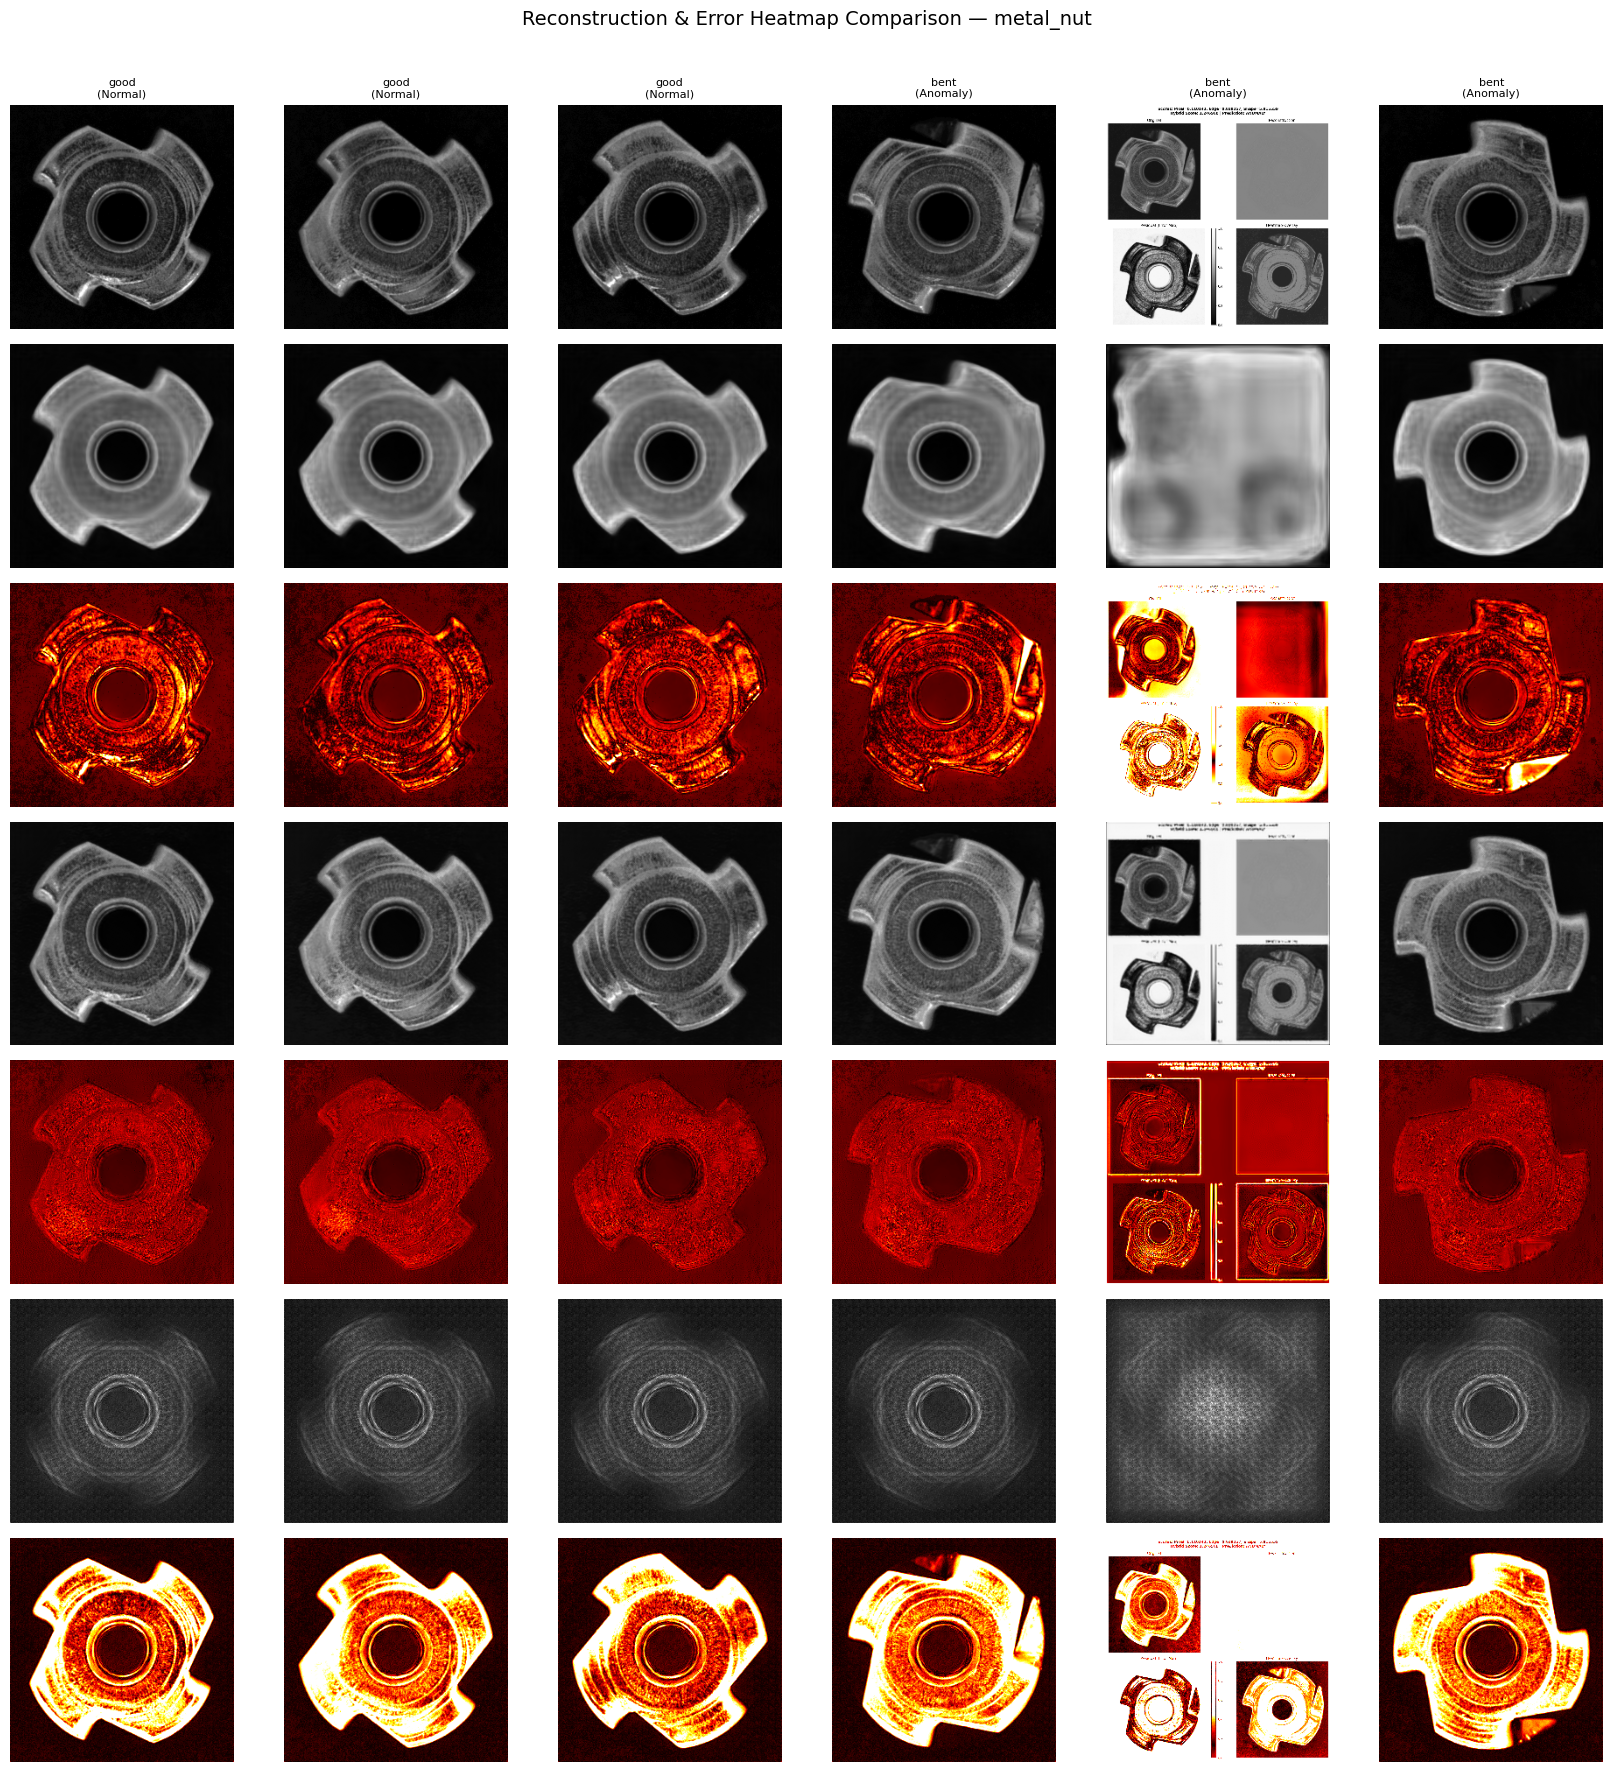

In [ ]:
# === RECONSTRUCTION & HEATMAP COMPARISON ===
test_ds_viz = MVTecDatasetAug(cfg, 'test', augment=False)
normal_idxs = [i for i, s in enumerate(test_ds_viz.samples) if s['label'] == 0]
anomaly_idxs = [i for i, s in enumerate(test_ds_viz.samples) if s['label'] == 1]
samples = [test_ds_viz[i] for i in normal_idxs[:3] + anomaly_idxs[:3]]
n_s = len(samples)
models_info = [("SimpleAE", all_models['SimpleAE'], False),
               ("AttentionUNet", all_models['AttentionUNet'], False),
               ("ConvVAE", all_models['ConvVAE'], True)]
fig, axes = plt.subplots(7, n_s, figsize=(2.8 * n_s, 17.5))
for j, s in enumerate(samples):
    axes[0, j].imshow(s['gray'].squeeze(), cmap='gray')
    axes[0, j].set_title(f"{s['defect']}\n({'Anomaly' if s['label'] else 'Normal'})", fontsize=8)
axes[0, 0].set_ylabel('Original', fontsize=10, fontweight='bold')
for mi, (name, mdl, vae) in enumerate(models_info):
    rr, rh = 1 + mi * 2, 2 + mi * 2
    mdl.eval()
    for j, s in enumerate(samples):
        with torch.no_grad():
            out = mdl(s['fused'].unsqueeze(0).to(device))
            recon = (out[0] if vae else out).cpu().squeeze().numpy()
        diff = np.abs(s['gray'].squeeze().numpy() - recon)
        axes[rr, j].imshow(recon, cmap='gray')
        axes[rh, j].imshow(diff, cmap='hot', vmin=0, vmax=cfg.heatmap_vmax)
    axes[rr, 0].set_ylabel(f'{name}\nRecon', fontsize=9, fontweight='bold')
    axes[rh, 0].set_ylabel(f'{name}\nError', fontsize=9, fontweight='bold')
for ax in axes.flat: ax.axis('off')
plt.suptitle(f'Reconstruction & Error — {cfg.category}', fontsize=14, y=1.01); plt.tight_layout()
plt.savefig(f'reconstruction_comparison_{cfg.category}.png', dpi=150, bbox_inches='tight'); plt.show()

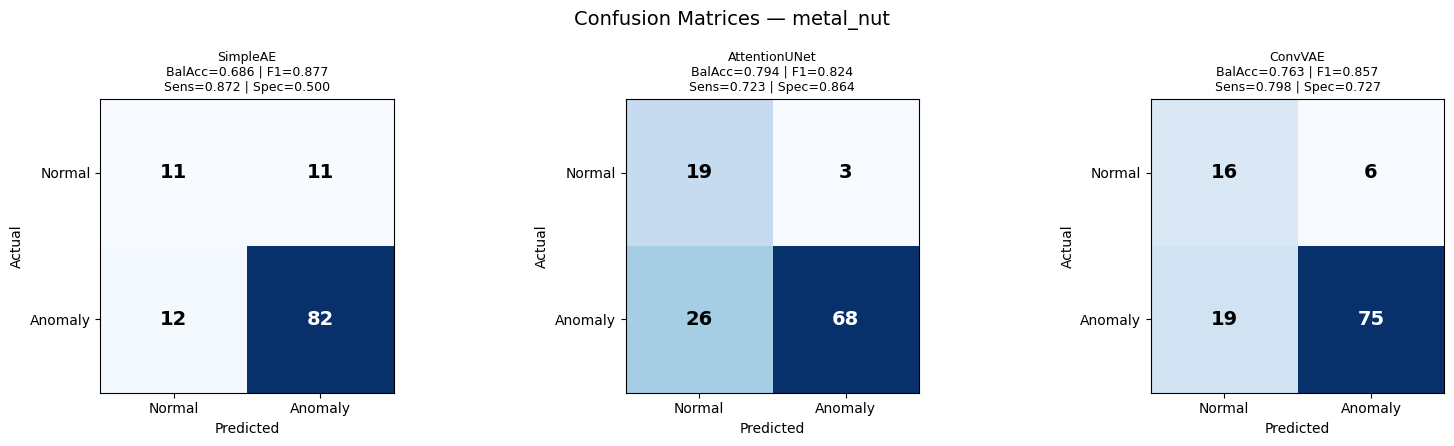

In [ ]:
# === CONFUSION MATRICES ===
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, res) in zip(axes, all_results.items()):
    cm = res['confusion_matrix']
    ax.imshow(cm, cmap='Blues', interpolation='nearest')
    ax.set_title(f"{name}\nBalAcc={res['balanced_accuracy']:.3f} F1={res['f1_score']:.3f}\n"
                 f"Sens={res['sensitivity']:.3f} Spec={res['specificity']:.3f}", fontsize=9)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Normal', 'Anomaly']); ax.set_yticklabels(['Normal', 'Anomaly'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14, fontweight='bold',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.suptitle(f'Confusion Matrices — {cfg.category}', fontsize=14); plt.tight_layout()
plt.savefig(f'confusion_matrices_{cfg.category}.png', dpi=150, bbox_inches='tight'); plt.show()

In [ ]:
# === SINGLE IMAGE INFERENCE ===

def predict_all_models(image_path, models_dict, cfg, results_dict=None):
    ssim_scorer = SSIMLoss().to(device)
    fused, gray = preprocess(image_path, cfg)
    x, y = fused.unsqueeze(0).to(device), gray.unsqueeze(0).to(device)
    n_m = len(models_dict)
    fig, axes = plt.subplots(3, n_m + 1, figsize=(4 * (n_m + 1), 10))
    axes[0, 0].imshow(gray.squeeze(), cmap='gray'); axes[0, 0].set_title('Input', fontweight='bold')
    axes[1, 0].axis('off'); axes[2, 0].axis('off')
    results_text = []

    for col, (name, mdl) in enumerate(models_dict.items(), 1):
        mdl.eval(); is_vae = isinstance(mdl, ConvVAE)
        with torch.no_grad():
            if is_vae: recon_t, mu, logvar = mdl(x)
            else: recon_t = mdl(x)
        mse_map = (y - recon_t) ** 2
        mse_score = mse_map.view(1, -1).mean(dim=1).item()
        img_sc, diff_sm = compute_anomaly_score(y, recon_t, ssim_loss_fn=ssim_scorer)
        combined_score = img_sc[0].item()
        k = max(1, int(mse_map.view(1, -1).size(1) * 0.02))
        perc_score = mse_map.view(1, -1).topk(k, dim=1)[0].mean(dim=1).item()
        vae_score = (mse_score + 0.1 * (-0.5 * (1 + logvar - mu.pow(2) - logvar.exp()).sum(dim=1).item())) if is_vae else None
        score_map = {'MSE': mse_score, 'MSE+SSIM': combined_score, 'Top-2%': perc_score,
                     'Recon+KL': vae_score, 'Combined': combined_score}
        method = results_dict[name].get('best_method', 'MSE+SSIM') if results_dict and name in results_dict else 'MSE+SSIM'
        display_score = score_map.get(method, combined_score) or combined_score
        thresh = results_dict[name]['threshold'] if results_dict and name in results_dict else None
        pred_label = ("ANOMALY" if display_score > thresh else "NORMAL") if thresh else f"{display_score:.6f}"
        pred_color = ('red' if display_score > thresh else 'green') if thresh else 'black'
        diff_np = diff_sm.cpu().squeeze()
        axes[0, col].imshow(recon_t.cpu().squeeze(), cmap='gray'); axes[0, col].set_title(f'{name}\nRecon', fontsize=9)
        axes[1, col].imshow(diff_np, cmap='hot', vmin=0, vmax=cfg.heatmap_vmax)
        axes[1, col].set_title(f'Error ({method})\n{display_score:.6f}', fontsize=9)
        axes[2, col].imshow(gray.squeeze(), cmap='gray')
        axes[2, col].imshow(diff_np, cmap='hot', alpha=0.5, vmin=0, vmax=cfg.heatmap_vmax)
        axes[2, col].set_title(pred_label, fontsize=10, fontweight='bold', color=pred_color)
        results_text.append(f"{name} [{method}]: {display_score:.6f} → {pred_label}")

    for r, lbl in enumerate(['Reconstruction', 'Error Map', 'Overlay']): axes[r, 0].set_ylabel(lbl, fontsize=10)
    for ax in axes.flat: ax.axis('off')
    plt.suptitle(f'Inference: {os.path.basename(image_path)}', fontsize=12); plt.tight_layout(); plt.show()
    for r in results_text: print(f"  {r}")
    return results_text

print("✅ Multi-model inference ready")

✅ Multi-model inference function ready (uses consistent scoring from evaluation)
   Usage: predict_all_models('path/to/image.png', all_models, cfg, all_results)


In [ ]:
# === EXPORT RESULTS ===
export_data = []
for n, r in all_results.items():
    np_ = sum(p.numel() for p in all_models[n].parameters() if p.requires_grad)
    cm = r['confusion_matrix']
    export_data.append({
        'Model': n, 'Category': cfg.category, 'Parameters': np_,
        'Image_AUROC': round(r['image_auroc'], 4), 'Pixel_AUROC': round(r['pixel_auroc'], 4),
        'Accuracy': round(r['accuracy'], 4), 'Balanced_Accuracy': round(r['balanced_accuracy'], 4),
        'F1_Score': round(r['f1_score'], 4), 'Sensitivity': round(r['sensitivity'], 4),
        'Specificity': round(r['specificity'], 4), 'Precision': round(r['precision'], 4),
        'Best_Method': r['best_method'], 'TN': cm[0, 0], 'FP': cm[0, 1], 'FN': cm[1, 0], 'TP': cm[1, 1],
    })
csv_path = f'model_comparison_{cfg.category}.csv'
pd.DataFrame(export_data).to_csv(csv_path, index=False)
print(f"📁 Results exported to {csv_path}")
print(f"\n📋 Config: {cfg.category} | {cfg.image_size}x{cfg.image_size} | bs={cfg.batch_size} | lr={cfg.lr}")
for n in all_models:
    print(f"  {n}: {sum(p.numel() for p in all_models[n].parameters() if p.requires_grad):,} params")
print(f"\n{'='*55}\n  ✅ ALL DONE — 3 models trained, evaluated, and compared!\n{'='*55}")

📁 Results exported to model_comparison_metal_nut.csv

📋 Configuration:
   Category:      metal_nut
   Image size:    256×256
   Batch size:    8
   Max epochs:    50
   Learning rate: 0.0001
   Augmentation:  HFlip, VFlip, Rotation(0/90/180/270)
   Loss:          MSE + SSIM + Edge + VGG Perceptual (+ KL for VAE)
   Scoring:       Multi-strategy with full combination search
   Early stop:    Validation-based, patience=10

📋 Models:
   SimpleAE: 4,124,865 parameters
   AttentionUNet: 8,025,507 parameters
   ConvVAE: 30,790,881 parameters

  ✅ ALL DONE — 3 models trained, evaluated, and compared!
